# Notebook 02: Preprocessing and Feature Extraction

## Overview
This notebook turns the image dataset into a numerical feature table that classical machine learning models can use. The order of steps matters. The data is split into train, validation, and test sets first, and only then is any preprocessing fitted, so that no information from the test set leaks into the training process. After the split, each image goes through Macenko stain normalisation and three families of feature extraction: colour, texture, and edge structure. The features are then scaled and reduced with PCA, using statistics learned from the training set alone.

## Objectives
1. Split the dataset into stratified train, validation, and test sets before any fitting.
2. Extract colour, GLCM, LBP, and HOG features from every image after Macenko normalisation.
3. Fit a StandardScaler on the training features only and apply it to all splits.
4. Fit PCA on the training features only and create a reduced feature set.
5. Save the feature tables, the fitted scaler, and the fitted PCA for the model notebooks.

## Note on order
Splitting before fitting the scaler and PCA is a strict rule of this project. Fitting a preprocessor on the whole dataset and then splitting would let the test set influence the training features, which inflates results and is a common mistake.

In [1]:
# ----- Environment setup -----
!pip install -q scikit-image seaborn joblib

from google.colab import drive
drive.mount('/content/drive')

import os, sys

# ---- Clone the project repository so notebooks can import from src/ ----
REPO       = "lung-colon-cancer-histopathology-ml"
REPO_LOCAL = "/content/" + REPO
REPO_URL   = "https://github.com/hodyek/" + REPO + ".git"

if not os.path.exists(REPO_LOCAL):
    !git clone $REPO_URL $REPO_LOCAL

# Insert at position 0 so our src/ always takes priority over any Colab defaults.
if REPO_LOCAL not in sys.path:
    sys.path.insert(0, REPO_LOCAL)

# Quick sanity-check that the import will work before running any cells.
import importlib.util
_spec = importlib.util.find_spec("src.dataset")
if _spec is None:
    raise ImportError(
        "src.dataset not found. Check that the clone succeeded and "
        "that src/__init__.py exists in the repository."
    )
print("src modules found at:", os.path.join(REPO_LOCAL, "src"))

# ---- Project folders on Google Drive ----
DRIVE_ROOT = "/content/drive/MyDrive/" + REPO
DATA_DIR   = "/content/drive/MyDrive/lung-colon-cancer-histopathology/data/lung_colon_image_set"
FIG_DIR    = os.path.join(DRIVE_ROOT, "figures")
MODEL_DIR  = os.path.join(DRIVE_ROOT, "models")
FEAT_DIR   = os.path.join(DRIVE_ROOT, "features")
for d in (FIG_DIR, MODEL_DIR, FEAT_DIR):
    os.makedirs(d, exist_ok=True)

CLASSES = ["colon_aca", "colon_n", "lung_aca", "lung_n", "lung_scc"]
print("Setup complete. CLASSES:", CLASSES)


Mounted at /content/drive
Cloning into '/content/lung-colon-cancer-histopathology-ml'...
remote: Enumerating objects: 96, done.
remote: Counting objects: 100% (96/96), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 96 (delta 29), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (96/96), 3.55 MiB | 2.92 MiB/s, done.
Resolving deltas: 100% (29/29), done.
src modules found at: /content/lung-colon-cancer-histopathology-ml/src
Setup complete. CLASSES: ['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc']


In [2]:
# Build the file table and create the stratified split.
import pandas as pd
from src.dataset import list_images, make_splits, CLASSES

df = list_images(DATA_DIR)
df = make_splits(df, seed=42, train_frac=0.70, val_frac=0.15)

# Save the manifest so every later notebook uses exactly the same split.
manifest_path = os.path.join(FEAT_DIR, "split_manifest.csv")
df.to_csv(manifest_path, index=False)

print("Split counts:")
print(pd.crosstab(df["split"], df["label"]))
print("\nManifest saved to:", manifest_path)

Split counts:
label  colon_aca  colon_n  lung_aca  lung_n  lung_scc
split                                                
test         750      750       750     751       750
train       3500     3500      3500    3499      3500
val          750      750       750     750       750

Manifest saved to: /content/drive/MyDrive/lung-colon-cancer-histopathology-ml/features/split_manifest.csv


The split divides the 25,000 images into 70 percent training, 15 percent validation, and 15 percent test, and the table shows each class is spread evenly across the three sets. Stratifying keeps the class balance the same in every split, which keeps the metrics fair. The split uses a fixed seed and is saved to a manifest file, so the train, validation, and test sets stay identical across all notebooks. Doing the split here, before any feature is fitted, is what prevents test data from leaking into training.

In [3]:
# Extract features for every image. This is the slow step and runs once.
# Features are cached to Google Drive so the model notebooks can load them fast.
import numpy as np
from tqdm import tqdm
from src.dataset import load_image
from src.features import extract_all_features

def extract_split(split_df):
    X, names = [], None
    for p in tqdm(split_df["path"].tolist()):
        img = load_image(p, size=224)
        vec, names = extract_all_features(img, apply_macenko=True)
        X.append(vec)
    return np.array(X, dtype=np.float32), names

feature_names = None
for split in ["train", "val", "test"]:
    cache = os.path.join(FEAT_DIR, f"X_{split}_raw.npy")
    ycache = os.path.join(FEAT_DIR, f"y_{split}.npy")
    if os.path.exists(cache):
        print(f"{split}: cached, skipping")
        continue
    sub = df[df["split"] == split].reset_index(drop=True)
    Xs, feature_names = extract_split(sub)
    np.save(cache, Xs)
    np.save(ycache, sub["y"].values)
    print(f"{split}: features {Xs.shape} saved")

# Save the feature names once (same for every split).
if feature_names is None:
    # recompute names from one image if extraction was fully cached
    _, feature_names = extract_all_features(load_image(df['path'].iloc[0]), apply_macenko=False)
import json
with open(os.path.join(FEAT_DIR, "feature_names.json"), "w") as f:
    json.dump(feature_names, f)
print("Feature count:", len(feature_names))

100%|██████████| 17499/17499 [3:12:16<00:00,  1.52it/s]


train: features (17499, 421) saved


100%|██████████| 3750/3750 [39:27<00:00,  1.58it/s]


val: features (3750, 421) saved


100%|██████████| 3751/3751 [39:15<00:00,  1.59it/s]

test: features (3751, 421) saved
Feature count: 421


This step reads every image, normalises the stain, and turns it into a row of 421 numbers describing colour, texture, and edge structure. It is the slowest part of the whole project and can take a while on the full dataset, which is why the result is cached to Drive and skipped on later runs. Each feature keeps a readable name, which becomes important in the explainability notebook. Once this cell finishes, the rest of the pipeline works on small numeric files instead of thousands of images.

In [4]:
# Fit the scaler and PCA on the training features only, then transform all splits.
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_train = np.load(os.path.join(FEAT_DIR, "X_train_raw.npy"))
X_val   = np.load(os.path.join(FEAT_DIR, "X_val_raw.npy"))
X_test  = np.load(os.path.join(FEAT_DIR, "X_test_raw.npy"))

# Standardise features. Fit on train only.
scaler = StandardScaler().fit(X_train)
Xtr_s = scaler.transform(X_train)
Xva_s = scaler.transform(X_val)
Xte_s = scaler.transform(X_test)

# PCA for the distance based models. Fit on train only.
pca = PCA(n_components=50, random_state=42).fit(Xtr_s)
Xtr_p = pca.transform(Xtr_s)
Xva_p = pca.transform(Xva_s)
Xte_p = pca.transform(Xte_s)

# Save everything for the model notebooks.
np.save(os.path.join(FEAT_DIR, "X_train_scaled.npy"), Xtr_s)
np.save(os.path.join(FEAT_DIR, "X_val_scaled.npy"), Xva_s)
np.save(os.path.join(FEAT_DIR, "X_test_scaled.npy"), Xte_s)
np.save(os.path.join(FEAT_DIR, "X_train_pca.npy"), Xtr_p)
np.save(os.path.join(FEAT_DIR, "X_val_pca.npy"), Xva_p)
np.save(os.path.join(FEAT_DIR, "X_test_pca.npy"), Xte_p)
joblib.dump(scaler, os.path.join(MODEL_DIR, "scaler.joblib"))
joblib.dump(pca, os.path.join(MODEL_DIR, "pca.joblib"))

print("Scaled feature shape:", Xtr_s.shape)
print("PCA feature shape:", Xtr_p.shape)
print("Variance kept by 50 components:", round(pca.explained_variance_ratio_.sum(), 4))

Scaled feature shape: (17499, 421)
PCA feature shape: (17499, 50)
Variance kept by 50 components: 0.8655


The scaler and PCA are both fitted only on the training features, then used to transform the validation and test sets, which keeps the test data unseen. Standardising puts every feature on the same scale so that distance and margin based models are not dominated by large valued features. The PCA version reduces 421 features to 50 components while keeping most of the variance, which speeds up the slower models. Two feature versions are saved: the full scaled set for tree based models and explainability, and the PCA set for the support vector machine and nearest neighbours.

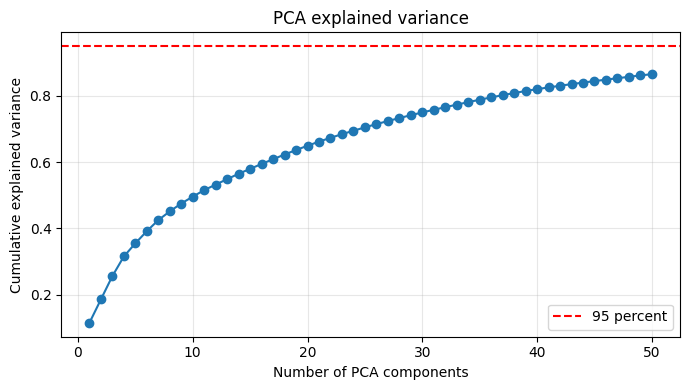

In [5]:
# Show how much variance the PCA components explain.
import matplotlib.pyplot as plt
import numpy as np

cum = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cum) + 1), cum, "o-")
plt.axhline(0.95, color="red", linestyle="--", label="95 percent")
plt.xlabel("Number of PCA components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA explained variance")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "02_pca_explained_variance.png"), dpi=150, bbox_inches="tight")
plt.show()

The curve shows how much of the total variation is captured as more components are added. The first handful of components carry most of the information, and the gain flattens out quickly after that. Choosing 50 components keeps a large share of the variance while cutting the feature count by almost ninety percent. This is a sensible trade because it keeps the strong signal and drops the noisy tail, which helps the support vector machine train faster without losing much accuracy.


The dataset was split into stratified train, validation, and test sets before any preprocessing was fitted, and the split was saved to a manifest for reuse. Every image was normalised and turned into a 421 value feature row covering colour, texture, and edge structure. A StandardScaler and a 50 component PCA were fitted on the training set only and applied to all splits. The full scaled features and the PCA features are now cached on Drive, ready for the model notebooks. The next notebook trains the baseline models.